# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [5]:
from IPython.display import SVG, display
import matplotlib.pyplot as plt

import os

# Replace '/path/to/new/cache' with your desired directory
os.environ["HF_HOME"] = "./.cache"
print(os.environ["HF_HOME"])

from datasets import load_dataset, concatenate_datasets, DatasetDict, Value

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim import AdamW
from pl_bolts.optimizers.lr_scheduler import LinearWarmupCosineAnnealingLR

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm
from scipy.optimize import curve_fit


import re
import time

./.cache


# 1. Data Collecting and Preprocessing


## 1.1 Datasets


In [6]:
# dataset_1 = load_dataset("starvector/svg-icons-simple")
# dataset_1 = dataset_1.cast_column("Filename", Value("string"))

# dataset_2 = load_dataset("starvector/svg-emoji-simple")
# dataset_2 = dataset_2.cast_column("Filename", Value("string"))

dataset_3 = load_dataset("starvector/svg-stack-simple")
dataset_3 = dataset_3.cast_column("Filename", Value("string"))

# Combine all splits using a dictionary comprehension
combined_dataset = DatasetDict(
    {
        split: concatenate_datasets(
            # [dataset_1[split], dataset_2[split], dataset_3[split]]
            [dataset_3[split]]
        )
        # for split in dataset_1.keys()
        for split in dataset_3.keys()
    }
)

total_items = 300000

dataset = combined_dataset["train"].select(range(total_items))

print(dataset)

Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 300000
})


### View Sample


In [7]:
sample_1 = dataset["Svg"][2]

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M12.0 2.5500001907348633 L12.0 2.5500001907348633 C13.606608390808105 2.709066390991211 15.104549407958984 3.060948371887207 16.43461799621582 3.7229955196380615 C17.764686584472656 4.385043144226074 18.926883697509766 5.357255458831787 19.862003326416016 6.756983280181885 C21.186187744140625 8.739078521728516 21.612411499023438 10.979890823364258 21.32829475402832 13.103455543518066 C21.044178009033203 15.227020263671875 20.049724578857422 17.23333740234375 18.532550811767578 18.746442794799805 C17.015378952026367 20.259550094604492 14.975489616394043 21.27944564819336 12.600503921508789 21.430166244506836 C9.992717742919922 21.595661163330078 7.695192337036133 20.690662384033203 5.961532115936279 19.17551040649414 C4.227871894836426 17.660358428955078 3.058077096939087 15.535049438476562 2.705751895904

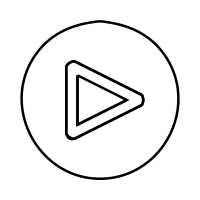

In [8]:
print(sample_1)
display(SVG(sample_1))

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [9]:
def clean_svg(svg_text):
    # 1. Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # 2. Function to clean ONLY the path data string
    def clean_path_data(match):
        path_string = match.group(1)

        # Space out the letters (M, L, C, Z, etc.)
        path_string = re.sub(r"([a-zA-Z])", r" \1 ", path_string)

        # Replace commas with spaces
        path_string = path_string.replace(",", " ")

        # Round numbers to 1 decimal place
        def round_match(m):
            try:
                return f"{float(m.group(0)):.1f}"
            except ValueError:
                return m.group(0)

        path_string = re.sub(r"-?\d*\.?\d+", round_match, path_string)

        # Clean up any messy double-spaces inside the quotes
        path_string = re.sub(r"\s+", " ", path_string).strip()

        # Return it wrapped back in d="..."
        return f'd="{path_string}"'

    # 3. Apply the cleaner ONLY to the d="..." attributes
    svg_text = re.sub(r'd="([^"]+)"', clean_path_data, svg_text)

    # 4. Clean up any overall messy whitespace
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text


# Example Test:
raw_svg = '<svg><path d="M10,20.35L.5 30"/></svg>'
print(clean_svg(raw_svg))

<svg><path d="M 10.0 20.4 L 0.5 30.0"/></svg>


In [10]:
svg_string = clean_svg(sample_1)
print(svg_string)

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 12.0 2.6 L 12.0 2.6 C 13.6 2.7 15.1 3.1 16.4 3.7 C 17.8 4.4 18.9 5.4 19.9 6.8 C 21.2 8.7 21.6 11.0 21.3 13.1 C 21.0 15.2 20.0 17.2 18.5 18.7 C 17.0 20.3 15.0 21.3 12.6 21.4 C 10.0 21.6 7.7 20.7 6.0 19.2 C 4.2 17.7 3.1 15.5 2.7 13.3 C 2.4 11.0 2.8 8.6 4.4 6.4 C 5.3 5.1 6.4 4.2 7.7 3.6 C 9.0 3.0 10.5 2.7 12.0 2.6 L 12.0 2.6"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 7.3 L 13.0 9.4 L 17.0 11.4 C 17.2 11.7 17.2 12.3 17.0 12.6 L 13.0 14.6 L 8.9 16.7 C 8.3 16.8 8.2 16.6 7.9 16.0 L 7.9 12.0 L 8.0 8.0 C 8.1 7.6 8.5 7.4 8.9 7.3 L 8.9 7.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 8.9 7.3 L 13.0 9.4 L 17.0 11.4 C 17.2 11.7 17.2 12.3 17.0 12.6 L 13.0 14.6 L 8.9 16.7 C 8.5 16.6 8.1 16.4 7.9 16.1 L 7.9 1

### Clean and verify all svgs in training set


In [11]:
TOKEN_THRESHOLD = 2048

In [12]:
from svg_utils import process_row

In [13]:
print("Cleaning datasets with multiprocessing...")
cleaned_dataset = dataset.map(process_row, num_proc=8)
print("Done!")

remaining_items = len(cleaned_dataset)
print(remaining_items)

Cleaning datasets with multiprocessing...
Done!
300000


In [14]:
stop_1 = int(remaining_items * 0.98)
stop_2 = stop_1 + int(remaining_items * 0.01)
stop_3 = stop_2 + int(remaining_items * 0.01)

cleaned_train = cleaned_dataset.select(range(stop_1))
cleaned_val = cleaned_dataset.select(range(stop_1, stop_2))
cleaned_test = cleaned_dataset.select(range(stop_2, stop_3))

In [15]:
cleaned_train

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 294000
})

In [16]:
cleaned_val

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 3000
})

In [17]:
cleaned_test

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 3000
})

In [18]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


# valid_render runs very long and hasn't filtered out any svg yet... SKIP!

# def valid_render(d):
#     svg_string = d["Svg"]

#     try:
#         cairosvg.svg2png(bytestring=svg_string.encode("utf-8"))
#     except:
#         return False

#     return True


filtered_train = cleaned_train.filter(is_valid)
# filtered_train = filtered_train.filter(valid_render)

In [19]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 204630


## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [20]:
# small initials

VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [21]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [22]:
try:
    tokenizer = Tokenizer.from_file("tokenizer.json")
except:
    print("No tokenizer found in root!")

    tokenizer = Tokenizer(models.BPE())

    tokenizer.pre_tokenizer = pre_tokenizers.Sequence(
        [pre_tokenizers.WhitespaceSplit(), pre_tokenizers.Punctuation()]
    )

    trainer = trainers.BpeTrainer(
        special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
    )

    tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

    tokenizer.save("tokenizer.json")

In [23]:
sample_2 = filtered_train["Svg"][0]
sample_2

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 19.0 7.7 L 22.3 7.7 C 22.4 7.8 22.6 8.0 22.8 8.2 L 22.8 11.7 C 22.6 11.8 22.4 12.0 22.3 12.2 L 19.0 12.2 C 18.8 12.0 18.7 11.8 18.5 11.7 L 18.5 8.2 C 18.7 8.0 18.8 7.8 19.0 7.7 L 19.0 7.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 1.9 7.7 L 5.2 7.7 C 5.4 7.8 5.6 8.0 5.7 8.2 L 5.7 11.7 C 5.6 11.8 5.4 12.0 5.2 12.2 L 1.9 12.2 C 1.8 12.0 1.6 11.8 1.5 11.7 L 1.5 8.2 C 1.6 8.0 1.8 7.8 1.9 7.7 L 1.9 7.7"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M 6.2 12.1 L 9.5 12.1 C 9.7 12.3 9.8 12.4 10.0 12.6 L 10.0 16.1 C 9.8 16.3 9.7 16.4 9.5 16.6 L 6.2 16.6 C 6.1 16.4 5.9 16.3 5.8 16.1 L 5.8 12.6 C 5.9 12.4 6.1 12.3 6.2 12.1 L 6.2 12.1"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1

In [24]:
encoded_sample_2 = tokenizer.encode(sample_2)

print(encoded_sample_2)


# First 10 tokens on encoding
for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
    print(f"{id} -> {token}")

Encoding(num_tokens=694, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
17 -> <
90 -> svg
116 -> xmlns
18 -> =
2 -> "
110 -> http
16 -> :
5 -> /
5 -> /
111 -> www


In [25]:
tokenizer.decode(encoded_sample_2.ids)

'< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 19 . 0 7 . 7 L 22 . 3 7 . 7 C 22 . 4 7 . 8 22 . 6 8 . 0 22 . 8 8 . 2 L 22 . 8 11 . 7 C 22 . 6 11 . 8 22 . 4 12 . 0 22 . 3 12 . 2 L 19 . 0 12 . 2 C 18 . 8 12 . 0 18 . 7 11 . 8 18 . 5 11 . 7 L 18 . 5 8 . 2 C 18 . 7 8 . 0 18 . 8 7 . 8 19 . 0 7 . 7 L 19 . 0 7 . 7 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 1 . 9 7 . 7 L 5 . 2 7 . 7 C 5 . 4 7 . 8 5 . 6 8 . 0 5 . 7 8 . 2 L 5 . 7 11 . 7 C 5 . 6 11 . 8 5 . 4 12 . 0 5 . 2 12 . 2 L 1 . 9 12 . 2 C 1 . 8 12 . 0 1 . 6 11 . 8 1 . 5 11 . 7 L 1 . 5 8 . 2 C 1 . 6 8 . 0 1 . 8 7 . 8 1 . 9 7 . 7 L 1 . 9 7 . 7 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 .

In [26]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [27]:
tokenized_train = filtered_train.map(tokenize_svg)

In [28]:
tokenized_train["input_ids"]

Column([[17, 90, 116, 18, 2, 110, 16, 5, 5, 111, 4, 108, 4, 114, 5, 96, 5, 90, 2, 115, 18, 2, 6, 4, 6, 6, 4, 6, 91, 4, 6, 91, 4, 6, 2, 113, 18, 2, 95, 2, 70, 18, 2, 95, 2, 19, 17, 58, 59, 18, 2, 85, 2, 52, 18, 2, 83, 2, 52, 3, 70, 18, 2, 4, 9, 2, 52, 3, 86, 18, 2, 7, 4, 6, 2, 87, 18, 2, 6, 2, 27, 18, 2, 23, 67, 4, 6, 13, 4, 13, 22, 72, 4, 9, 13, 4, 13, 21, 72, 4, 10, 13, 4, 14, 72, 4, 12, 14, 4, 6, 72, 4, 14, 14, 4, 8, 22, 72, 4, 14, 62, 4, 13, 21, 72, 4, 12, 62, 4, 14, 72, 4, 10, 53, 4, 6, 72, 4, 9, 53, 4, 8, 22, 67, 4, 6, 53, 4, 8, 21, 66, 4, 14, 53, 4, 6, 66, 4, 13, 62, 4, 14, 66, 4, 11, 62, 4, 13, 22, 66, 4, 11, 14, 4, 8, 21, 66, 4, 13, 14, 4, 6, 66, 4, 14, 13, 4, 14, 67, 4, 6, 13, 4, 13, 22, 67, 4, 6, 13, 4, 13, 2, 19, 17, 5, 58, 19, 17, 58, 59, 18, 2, 85, 2, 52, 18, 2, 83, 2, 52, 3, 70, 18, 2, 4, 9, 2, 52, 3, 86, 18, 2, 7, 4, 6, 2, 87, 18, 2, 6, 2, 27, 18, 2, 23, 7, 4, 15, 13, 4, 13, 22, 11, 4, 8, 13, 4, 13, 21, 11, 4, 10, 13, 4, 14, 11, 4, 12, 14, 4, 6, 11, 4, 13, 14, 4, 8, 22, 

In [29]:
def flatten_input_ids(tokenized_dataset):
    concat_arr = []

    for arr in tqdm(tokenized_dataset["input_ids"]):
        concat_arr.extend(arr)

    return concat_arr


train_input_ids = flatten_input_ids(tokenized_train)
train_input_ids = np.array(train_input_ids)

len(train_input_ids)

  0%|          | 0/204630 [00:00<?, ?it/s]

130428077

### Create, clean, filter, and tokenize test/val datasets


In [30]:
filtered_test = cleaned_test.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)
test_input_ids = flatten_input_ids(tokenized_test)
test_input_ids = np.array(test_input_ids)

filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)
val_input_ids = flatten_input_ids(tokenized_val)
val_input_ids = np.array(val_input_ids)

  0%|          | 0/2066 [00:00<?, ?it/s]

  0%|          | 0/2088 [00:00<?, ?it/s]

In [31]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 133084710
Number of tokens in train: 130428077 -> 98.00%
Number of tokens in val: 1355632 -> 1.02%
Number of tokens in test: 1301001 -> 0.98%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


## 2.0 Dataloaders


In [32]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Convert to 1D tensors
train_data = torch.tensor(train_input_ids, dtype=torch.long)
val_data = torch.tensor(val_input_ids, dtype=torch.long)

# We want sequences of length (BLOCK_SIZE + 1)
# Assuming you still have BLOCK_SIZE = 256 from your earlier cell
seq_len = BLOCK_SIZE + 1


def chunk_data(data, seq_len):
    # Calculate how many full sequences we can make
    num_chunks = len(data) // seq_len

    # Truncate any leftover tokens at the very end that don't fit into a full chunk
    data = data[: num_chunks * seq_len]

    # Reshape the 1D tensor into a 2D grid of shape (num_chunks, seq_len)
    return data.view(num_chunks, seq_len)


# 2. Reshape 1D streams into 2D grids
train_data_2d = chunk_data(train_data, seq_len)
val_data_2d = chunk_data(val_data, seq_len)

# 3. NOW we can slice into X and Y safely!
# X gets everything except the last token of each chunk
X_train = train_data_2d[:, :-1]
# Y gets everything except the first token of each chunk
Y_train = train_data_2d[:, 1:]

X_val = val_data_2d[:, :-1]
Y_val = val_data_2d[:, 1:]

# 4. Bundle into TensorDataset and DataLoader
train_dataset = TensorDataset(X_train, Y_train)
val_dataset = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

print(f"X shape: {X_train.shape}, Y shape: {Y_train.shape}")

X shape: torch.Size([507502, 256]), Y shape: torch.Size([507502, 256])


## 2.1 Define Model and Functions


In [33]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        # 'tril' is the lower triangular matrix for masking
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (n_embd)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * (C**-0.5)

        # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        output = F.softmax(wei, dim=-1) @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()

        head_size = d_model // n_heads

        self.heads = nn.ModuleList(
            [Head(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):

        # Runs input through each attention head, and glues them together side-by-side
        x = torch.concat([head(x) for head in self.heads], dim=-1)

        # Mixes the (head_size x n_heads) head outputs back to one d_model dimensional layer
        x = self.proj(x)

        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class CustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)

    def generate(self, idx, max_new_tokens, temperature=0.8):
        # idx.shape (B,T)

        for _ in range(max_new_tokens):

            # Crop to block_size if too long
            if idx.size(1) <= self.block_size:
                idx_continue = idx
            else:
                idx_continue = idx[:, -self.block_size :]

            # forward into model.
            logits, _ = self(idx_continue)

            # Get the final step logits
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            # sample randomly from the distribution
            # print(probs.shape)
            idx_next = torch.multinomial(probs, num_samples=1)

            # append the new index to the sequence and continue
            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [34]:
def estimate_loss(model, val_loader, eval_iters=50):

    model.eval()
    with torch.inference_mode():
        losses = torch.zeros(eval_iters)
        val_iter = iter(val_loader)

        for k in range(eval_iters):
            try:
                X, Y = next(val_iter)
            except StopIteration:
                val_iter = iter(val_loader)
                X, Y = next(val_iter)

            X, Y = X.to(device), Y.to(device)

            _, loss = model(X, targets=Y)

            losses[k] = loss.item()

    model.train()
    return losses.mean().item()


def train_loop(
    model, optimizer, train_loader, val_loader, steps, scheduler=None, eval_interval=100
):
    model.train()
    train_iter = iter(train_loader)

    # --- METRICS TRACKING ---
    train_loss_history = []
    total_tokens_processed = 0
    start_time = time.time()

    # Reset GPU memory stats if using CUDA
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    for step in range(steps):
        try:
            X, Y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            X, Y = next(train_iter)

        X, Y = X.to(device), Y.to(device)
        total_tokens_processed += X.numel()  # Batch_size * Sequence_length

        _, loss = model(X, targets=Y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )  # Clipping gradients
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        train_loss_history.append(loss.item())

        if step % eval_interval == 0 or step == steps - 1:
            current_lr = optimizer.param_groups[0]["lr"]
            val_loss = estimate_loss(model, val_loader)
            print(
                f"Step {step:04d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f} | lr: {current_lr:.9e}"
            )

    # --- FINALIZE METRICS ---
    end_time = time.time()
    wall_clock_time = end_time - start_time
    tokens_per_sec = total_tokens_processed / wall_clock_time

    max_mem_mb = 0
    if torch.cuda.is_available():
        max_mem_mb = torch.cuda.max_memory_allocated(device) / (1024**2)

    final_val_loss = estimate_loss(model, val_loader)

    return {
        "final_val_loss": final_val_loss,
        "train_loss_history": train_loss_history,
        "wall_clock_time": wall_clock_time,
        "tokens_per_sec": tokens_per_sec,
        "gpu_memory_mb": max_mem_mb,
    }

## 2.2 Single Burn Run


In [45]:
def render_svg(s):
    path_strings = re.findall(r'd\s*=\s*"([^"]+)"', s)

    clean_paths = []
    for path_data in path_strings:
        # Clean up tokenizer spaces around dots and numbers (e.g., "1 . 0" -> "1.0")
        clean_data = re.sub(r"\s*\.\s*", ".", path_data)

        # Wrap it in a perfectly formatted path tag
        clean_paths.append(
            f'<path fill="none" stroke="black" stroke-width="0.5" d="{clean_data}" />'
        )

    # 2. Inject the paths into a clean, hardcoded SVG shell
    final_svg = f"""<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="200" height="200">
        {''.join(clean_paths)}
    </svg>"""

    print("--- Extracted and Cleaned SVG ---")
    print(final_svg)
    print("\n--- Rendered Image ---")

    try:
        display(SVG(final_svg))
    except Exception as e:
        print(f"Failed to render: {e}")

In [37]:
model = CustomTransformer(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_layers=4,
    n_heads=4,
    d_model=128,
    d_ff=512,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"total_params: {total_params}")

total_params: 1081576


tensor([[17, 90]], device='cuda:0')
torch.Size([1, 2])
torch.Size([1, 102])
[17, 90, 116, 18, 2, 115, 18, 2, 6, 4, 6, 6, 4, 6, 91, 4, 6, 2, 113, 18, 2, 95, 2, 70, 18, 2, 95, 2, 19, 17, 58, 59, 18, 2, 85, 2, 52, 18, 2, 83, 2, 52, 3, 70, 18, 2, 4, 9, 2, 52, 3, 86, 18, 2, 7, 4, 6, 2, 87, 18, 2, 6, 2, 27, 18, 2, 23, 9, 4, 6, 10, 4, 11, 22, 13, 4, 8, 10, 4, 11, 22, 53, 4, 6, 10, 4, 11, 22, 64, 4, 6, 12, 4, 11, 22, 61, 4, 6, 15, 4, 11, 22, 0]
< svg xmlns = " viewBox = " 0 . 0 0 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 3 . 0 4 . 5 L 7 . 2 4 . 5 L 12 . 0 4 . 5 L 16 . 0 6 . 5 L 15 . 0 9 . 5 L
--- Extracted and Cleaned SVG ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24" width="200" height="200">
        
    </svg>

--- Rendered Image ---


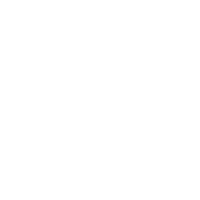

In [46]:
model.eval()

with torch.inference_mode():

    # start_point = torch.randint(1, VOCAB_SIZE, size=(1, 1), device=device)
    start_context = tokenizer.encode("<svg ").ids
    # print(start_context)
    start_point = torch.tensor([start_context], device=device)

    print(start_point)
    print(start_point.shape)

    result = model.generate(start_point, 100)
    print(result.shape)
    result = result.squeeze(0).cpu().tolist()
    result.append(0)

    print(result)

    decoded = tokenizer.decode(result)

    print(decoded)

render_svg(decoded)

In [41]:
optimizer = AdamW(model.parameters())

temp_train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
temp_val_loader = DataLoader(val_dataset, batch_size=64)

train_loop(model, optimizer, temp_train_loader, temp_val_loader, steps=1000)

Step 0000 | Train Loss: 7.0278 | Val Loss: 6.4375 | lr: 1.000000000e-03
Step 0100 | Train Loss: 1.8819 | Val Loss: 1.8407 | lr: 1.000000000e-03
Step 0200 | Train Loss: 1.4345 | Val Loss: 1.4780 | lr: 1.000000000e-03
Step 0300 | Train Loss: 1.2121 | Val Loss: 1.2150 | lr: 1.000000000e-03
Step 0400 | Train Loss: 1.1776 | Val Loss: 1.1348 | lr: 1.000000000e-03
Step 0500 | Train Loss: 1.0357 | Val Loss: 1.0607 | lr: 1.000000000e-03
Step 0600 | Train Loss: 0.9186 | Val Loss: 0.9648 | lr: 1.000000000e-03
Step 0700 | Train Loss: 0.8929 | Val Loss: 0.9139 | lr: 1.000000000e-03
Step 0800 | Train Loss: 0.9148 | Val Loss: 0.8820 | lr: 1.000000000e-03
Step 0900 | Train Loss: 0.8544 | Val Loss: 0.8626 | lr: 1.000000000e-03
Step 0999 | Train Loss: 0.8573 | Val Loss: 0.8485 | lr: 1.000000000e-03


{'final_val_loss': 0.8485230803489685,
 'train_loss_history': [7.0277862548828125,
  6.447120189666748,
  5.884666442871094,
  5.410761833190918,
  5.080776214599609,
  4.812967300415039,
  4.5861101150512695,
  4.424662113189697,
  4.239686965942383,
  4.101380825042725,
  3.926568031311035,
  3.7930030822753906,
  3.638195514678955,
  3.5022664070129395,
  3.4079742431640625,
  3.297926664352417,
  3.1968483924865723,
  3.087014675140381,
  2.983715534210205,
  2.9128050804138184,
  2.8475584983825684,
  2.836729049682617,
  2.713578462600708,
  2.688075304031372,
  2.6118886470794678,
  2.615227699279785,
  2.4665348529815674,
  2.4848856925964355,
  2.437720775604248,
  2.406857967376709,
  2.3563392162323,
  2.286752462387085,
  2.2338967323303223,
  2.2466819286346436,
  2.2707324028015137,
  2.189480781555176,
  2.2445333003997803,
  2.1166203022003174,
  2.1198906898498535,
  2.1288561820983887,
  2.1131606101989746,
  2.0425596237182617,
  2.0889859199523926,
  2.1320242881774

< svg xmlns = " http : / / www . w3 . org / 2000 / svg " viewBox = " 0 . 0 0 . 0 24 . 0 24 . 0 " height = " 200px " width = " 200px " > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 3 . 9 2 . 9 L 11 . 7 2 . 9 L 20 . 3 2 . 9 C 21 . 1 2 . 3 23 . 9 2 . 3 21 . 0 3 . 9 L 21 . 0 9 . 0 L 20 . 8 15 . 5 L 20 . 4 22 . 1 L 20 . 8 22 . 8 L 9 . 2 22 . 8 L 3 . 3 22 . 2 L 3 . 3 15 . 2 L 3 . 3 8 . 8 L 3 . 2 3 . 8 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 9 . 6 6 . 4 L 9 . 4 6 . 4 L 9 . 6 4 . 4 L 12 . 0 3 . 4 L 18 . 9 3 . 4 L 18 . 3 3 . 4 L 18 . 3 1 . 4 L 16 . 3 8 . 4 L 16 . 3 15 . 4 L 14 . 3 10 . 8 L 16 . 4 7 . 2 L 12 . 4 10 . 2 L 9 . 4 11 . 2 L 9 . 2 6 . 2 L 10 . 6 6 . 2 L 11 . 9 4 . 2 " > < / path > < path fill = " none " stroke = " black " stroke - width = " . 3 " stroke - opacity = " 1 . 0 " filling = " 0 " d = " M 14 . 8 6 . 8 L 15 

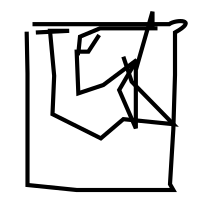

In [48]:
model.eval()

with torch.inference_mode():
    result_trained = model.generate(start_point, 500)

    result_trained = result_trained.squeeze(0).cpu().tolist()

    result_trained.append(0)

    # # result_trained.append[start_point]

    decoded_trained = tokenizer.decode(result_trained)

    print(decoded_trained)

render_svg(decoded_trained)

## 2.3 LR Sweep


In [49]:
# Straight from the assignment pdf
configs = {
    "Tiny": {"d_model": 128, "n_layers": 4, "n_heads": 4, "d_ff": 512},
    # "Small": {"d_model": 192, "n_layers": 6, "n_heads": 6, "d_ff": 768},
    # "Medium": {"d_model": 384, "n_layers": 6, "n_heads": 6, "d_ff": 1536},
    # "Large": {"d_model": 512, "n_layers": 10, "n_heads": 7, "d_ff": 2048},
    # "XL": {"d_model": 768, "n_layers": 12, "n_heads": 12, "d_ff": 3072},
}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [50]:
lrs = np.logspace(-7, -1, num=7)
print(lrs)

[1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01]


In [ ]:
lr_results = []
sweep_steps = 1000

print("Starting Learning Rate Sweep on Tiny Model...")

for lr in lrs:
    print(f"\n--- Testing LR: {lr:.1e} ---")

    # 1. RE-INITIALIZE THE MODEL inside the loop so it starts fresh!
    sweep_model = CustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=TOKEN_THRESHOLD, **configs["Tiny"]
    ).to(device)

    # 2. Initialize the optimizer with the current LR
    optimizer = AdamW(sweep_model.parameters(), lr=lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=100,  # e.g., 100 warmup steps
        max_epochs=sweep_steps,  # Total training steps
        warmup_start_lr=0.0,  # Warmup starts at 0.0
        eta_min=lr * 0.1,  # Cosine decays down to 10% of max LR
    )

    # 3. Train the model
    # (Replace `train_loop` with whatever your actual training function/loop is called)
    metrics = train_loop(
        sweep_model,
        optimizer,
        train_loader,
        val_loader,
        steps=sweep_steps,
        scheduler=scheduler,
    )

    # For demonstration, assign your actual returned val_loss here
    # val_loss = 0.0

    lr_results.append(metrics["final_val_loss"])
    print(f"Final Val Loss for LR {lr:.1e}: {metrics['final_val_loss']:.4f}")

Starting Learning Rate Sweep on Tiny Model...

--- Testing LR: 1.0e-07 ---


C:\Users\Vince\AppData\Local\Temp\ipykernel_24452\1121816641.py:17: UnderReviewWarning: The feature LinearWarmupCosineAnnealingLR is currently marked under review. The compatibility with other Lightning projects is not guaranteed and API may change at any time. The API and functionality may change without warning in future releases. More details: https://lightning-bolts.readthedocs.io/en/latest/stability.html
  scheduler = LinearWarmupCosineAnnealingLR(


Step 0000 | Train Loss: 7.0209 | Val Loss: 7.0238 | lr: 1.010101010e-09
Step 0100 | Train Loss: 7.0222 | Val Loss: 7.0210 | lr: 9.999972584e-08
Step 0200 | Train Loss: 7.0240 | Val Loss: 7.0155 | lr: 9.723218602e-08
Step 0300 | Train Loss: 7.0144 | Val Loss: 7.0103 | lr: 8.937082129e-08
Step 0400 | Train Loss: 7.0051 | Val Loss: 7.0056 | lr: 7.736382825e-08
Step 0500 | Train Loss: 7.0062 | Val Loss: 7.0017 | lr: 6.265942746e-08
Step 0600 | Train Loss: 6.9994 | Val Loss: 6.9987 | lr: 4.703118669e-08
Step 0700 | Train Loss: 7.0014 | Val Loss: 6.9965 | lr: 3.236410240e-08
Step 0800 | Train Loss: 6.9939 | Val Loss: 6.9950 | lr: 2.042724144e-08


In [ ]:
# best_lr = 1e-2
best_lr = lrs[np.argmax(lr_results)]

print(f"Lowest val_loss when lr = {best_lr}")

## 2.4 Train Model Family


In [ ]:
scaling_results = {}

steps_per_epoch = len(train_loader)
print(
    f"Starting Scaling Laws Experiment with Best LR = {best_lr} (1 Epoch = {steps_per_epoch} steps)"
)

for name, config in configs.items():
    print(f"\\n{'='*40}")
    print(f"Training {name} Model")
    print(f"{'='*40}")

    # Initialize the model with the specific config
    model = CustomTransformer(
        vocab_size=VOCAB_SIZE, block_size=TOKEN_THRESHOLD, **config
    ).to(device)

    params = count_parameters(model)
    print(f"Parameters: {params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr)

    scheduler = LinearWarmupCosineAnnealingLR(
        optimizer,
        warmup_epochs=int(steps_per_epoch * 0.1),
        max_epochs=steps_per_epoch,
        warmup_start_lr=0.0,
        eta_min=best_lr * 0.1,  # Decay to 10% of max LR
    )

    metrics = train_loop(
        model,
        optimizer,
        train_loader,
        val_loader,
        steps=steps_per_epoch,
        scheduler=scheduler,
        eval_interval=500,
    )

    # Print the requested tracking metrics
    print(f"✅ {name} Finished!")
    print(f"   Final Val Loss: {metrics['final_val_loss']:.4f}")
    print(f"   Wall-clock time: {metrics['wall_clock_time']:.1f} sec")
    print(f"   Throughput: {metrics['tokens_per_sec']:,.0f} tokens/sec")
    print(f"   Peak GPU Memory: {metrics['gpu_memory_mb']:.1f} MB")

    # Save for plotting
    metrics["params"] = params
    scaling_results[name] = metrics

    # Optional: Save the model weights so you can generate SVGs later
    torch.save(model.state_dict(), f"model_{name.lower()}.pt")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Extract the data
params_list = np.array([res["params"] for res in scaling_results.values()])
losses_list = np.array([res["final_val_loss"] for res in scaling_results.values()])
names = list(scaling_results.keys())


# 2. Define the Power Law Equation: L(N) = a * N^(-alpha) + c
def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c


# 3. Fit the curve! (We provide standard starting guesses [a=1, alpha=0.1, c=0.5])
popt, _ = curve_fit(
    power_law, params_list, losses_list, p0=[1.0, 0.1, 0.5], maxfev=10000
)
a_fit, alpha_fit, c_fit = popt

print(f"🎯 FITTED SCALING EXPONENT (alpha): {alpha_fit:.4f}")

# ==========================================
# Plot 1: The Power Law Scaling Curve
# ==========================================
plt.figure(figsize=(10, 6))

# Plot actual data points
plt.scatter(
    params_list, losses_list, color="red", s=100, zorder=5, label="Empirical Models"
)

# Generate smooth line for the fitted curve
x_smooth = np.logspace(
    np.log10(min(params_list) * 0.8), np.log10(max(params_list) * 1.2), 100
)
y_smooth = power_law(x_smooth, *popt)
plt.plot(
    x_smooth,
    y_smooth,
    "b--",
    linewidth=2,
    label=f"Fit: $L = {a_fit:.2f} \cdot N^{{-{alpha_fit:.3f}}} + {c_fit:.2f}$",
)

plt.xscale("log")
for i, name in enumerate(names):
    plt.annotate(
        name,
        (params_list[i], losses_list[i]),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
    )

plt.title("Validation Loss vs Parameter Count (Power Law)", fontsize=14)
plt.xlabel("Parameters N (Log Scale)")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# ==========================================
# Plot 2: Training Loss Curves
# ==========================================
plt.figure(figsize=(10, 6))
for name, res in scaling_results.items():
    # Apply a moving average to smooth the noisy batch losses
    window = max(1, len(res["train_loss_history"]) // 50)
    smoothed_loss = np.convolve(
        res["train_loss_history"], np.ones(window) / window, mode="valid"
    )
    plt.plot(smoothed_loss, label=f"{name} ({res['params']:,} params)", linewidth=2)

plt.title("Training Loss vs. Steps", fontsize=14)
plt.xlabel("Training Steps")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.show()